## 00 Import

In [2]:
import random
import requests
from datetime import datetime
import time
import os
from dotenv import load_dotenv
import pandas as pd
import logging
from pathlib import Path
from tqdm import tqdm
from stock_api import Buy_Stock, Sell_Stock, Get_User_Stocks
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Noto Sans CJK SC'
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()
log_path = Path("/app/logs/error.log")
log_path.parent.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler()
    ],
    force=True,
)

ACCOUNT = os.getenv('STOCK_ACCOUNT_USERNAME')
PASSWORD = os.getenv('STOCK_ACCOUNT_PASSWORD')
PG_URI = os.getenv('POSTGRES_URI')
CATEGORY_TABLE = 'model_comparison_per_category'
STOCK_TABLE = 'model_comparison_per_stock'

In [3]:
import twstock
stock = twstock.realtime.get('2330')
print(stock)

# stock
# print(Get_User_Stocks(ACCOUNT, PASSWORD))

{'timestamp': 1779172200.0, 'info': {'code': '2330', 'channel': '2330.tw', 'name': '台積電', 'fullname': '台灣積體電路製造股份有限公司', 'time': '2026-05-19 14:30:00'}, 'realtime': {'latest_trade_price': '2205.0000', 'trade_volume': '8037', 'accumulate_trade_volume': '34716', 'best_bid_price': ['2205.0000', '2200.0000', '2195.0000', '2190.0000', '2185.0000'], 'best_bid_volume': ['821', '2435', '870', '1224', '587'], 'best_ask_price': ['2210.0000', '2215.0000', '2220.0000', '2225.0000', '2230.0000'], 'best_ask_volume': ['31', '202', '567', '584', '862'], 'open': '2220.0000', 'high': '2230.0000', 'low': '2205.0000'}, 'success': True}


## 01 Model Performance

In [4]:
df_eval_category = pd.read_sql(f"SELECT * FROM {CATEGORY_TABLE}", PG_URI)
df_eval_stock = pd.read_sql(f"SELECT * FROM {STOCK_TABLE}", PG_URI)

In [5]:
df_eval_category.head()

,run_date,category,model,train_start,train_end,test_start,test_end,test_r2,test_rmse,pred_mean_ret,actual_mean_ret,next_day_pred_ret
0,2026-05-19,ETF,AR(5),2020-01-01,2026-04-18,2026-04-19,2026-05-19,-0.113032,0.024870,0.000758,0.007440,0.001664
1,2026-05-19,ETF,LSTM,2020-01-01,2026-04-18,2026-04-19,2026-05-19,-0.031262,0.024900,0.006625,0.007440,0.006877
2,2026-05-19,ETF,MA(5),2020-01-01,2026-04-18,2026-04-19,2026-05-19,-0.147298,0.025682,0.009393,0.007440,-0.003823
3,2026-05-19,ETF,Naive,2020-01-01,2026-04-18,2026-04-19,2026-05-19,-0.921632,0.033726,0.007476,0.007440,0.003141
4,2026-05-19,半導體業,AR(5),2020-01-01,2026-04-18,2026-04-19,2026-05-19,-0.076777,0.049680,0.001352,0.011947,0.002125


/tmp/ipykernel_71636/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_71636/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_71636/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_71636/707469830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_71636/707469830.py:15: UserWarning: set_ticklabels() shou

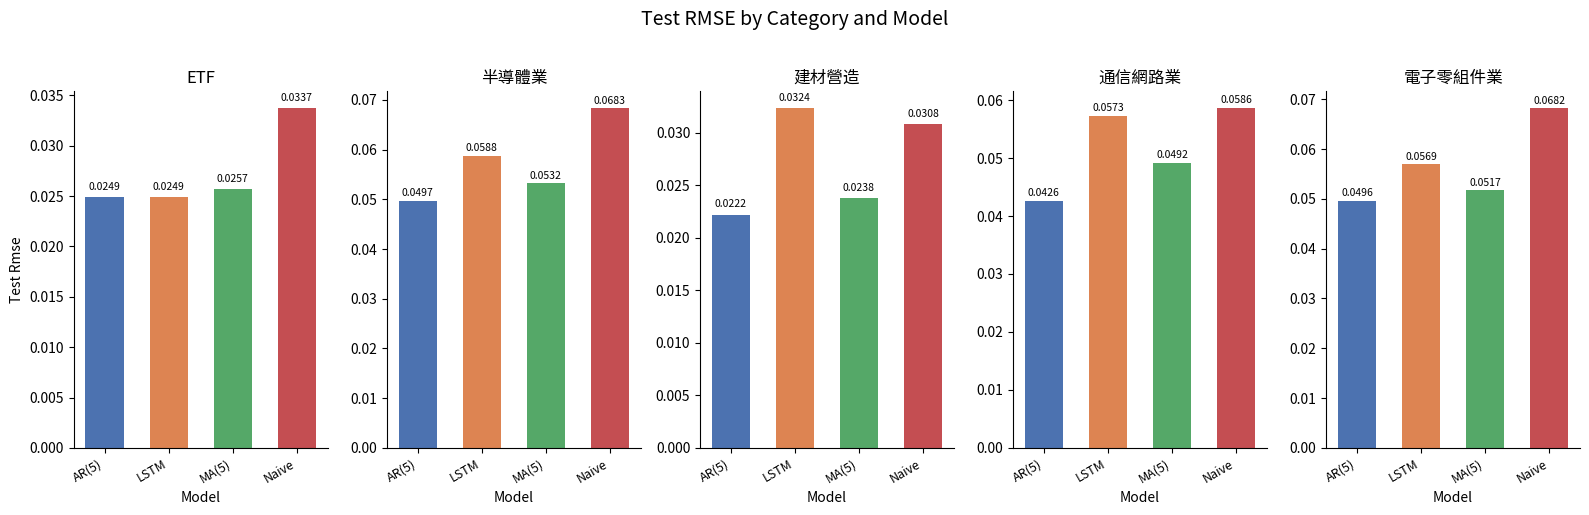

In [8]:
def plot_comparison_by_category(df_eval_category, target_col:str, title:str):
    categories = df_eval_category['category'].unique()
    models = df_eval_category['model'].unique()
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, axes = plt.subplots(1, len(categories), figsize=(16, 5), sharey=False)

    for ax, category in zip(axes, categories):
        subset = df_eval_category[df_eval_category['category'] == category].set_index('model')
        vals = [subset.loc[m, target_col] if m in subset.index else 0 for m in models]
        bars = ax.bar(models, vals, color=colors, width=0.6)
        ax.set_title(category, fontsize=12)
        ax.set_xlabel('Model')
        ax.set_ylabel(target_col.replace('_', ' ').title() if ax == axes[0] else '')
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_comparison_by_category(df_eval_category, 'test_rmse', 'Test RMSE by Category and Model')


In [12]:
import pandas_market_calendars as mcal

# Create Date list
START_DATE = datetime.strptime("2020-01-01", "%Y-%m-%d")
END_DATE = datetime.now().strftime("%Y-%m-%d")

date_list_original = pd.date_range(start=START_DATE, end=END_DATE, freq='D')  # 生成所有工作日的日期列表

twse = mcal.get_calendar('XTAI')  # 台灣證交所
schedule = twse.schedule(start_date='2020-01-01', end_date=END_DATE)
date_list = schedule.index.strftime('%Y%m%d').tolist()
print(f"Normal days count: {len(date_list_original)}, Trading days count: {len(date_list)}")


Normal days count: 2331, Trading days count: 1549


## END